In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("456Social_Network_Ads.csv")
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [ ]:
X = df[['Age', 'EstimatedSalary']]   # Independent variables
y = df['Purchased']                  # Dependent variable

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [ ]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[65  3]
 [ 8 24]]
Accuracy: 0.89


In [ ]:
# Example prediction (Age=30, Salary=50000)
new_data = sc.transform([[30, 50000]])
prediction = model.predict(new_data)

print("Will Purchase (1=Yes, 0=No):", prediction)

Will Purchase (1=Yes, 0=No): [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


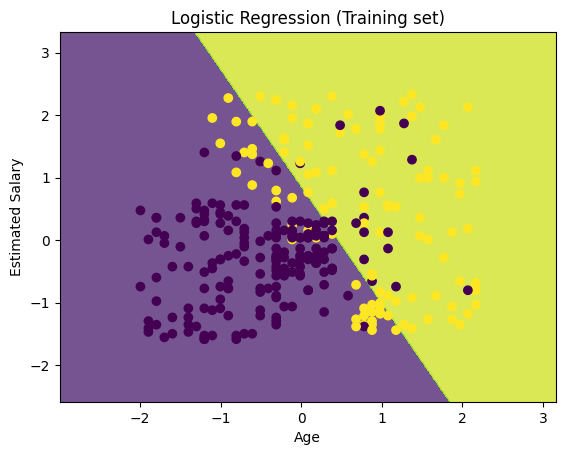

In [ ]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(
    np.arange(X_set[:,0].min()-1, X_set[:,0].max()+1, 0.01),
    np.arange(X_set[:,1].min()-1, X_set[:,1].max()+1, 0.01)
)

plt.contourf(X1, X2, model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75)

plt.scatter(X_set[:,0], X_set[:,1], c=y_set)
plt.title("Logistic Regression (Training set)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()